In [3]:
import numpy as np
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import pairwise_distances
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.cluster import KMeans

# ----------------------------
# Toy dataset
# ----------------------------
X, y = make_classification(
    n_samples=1000, n_features=10, n_informative=6, n_redundant=0,
    n_classes=2, class_sep=1.2, random_state=42
)

# Split into a tiny labeled seed set and a big unlabeled pool
rng = np.random.default_rng(0)
idx = rng.permutation(len(X))
L = idx[:20]      # labeled indices
U = idx[20:]      # unlabeled indices

# A simple model we’ll train on the labeled set
model = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=0))
model.fit(X[L], y[L])

# ----------------------------
# Strategy 1: Uncertainty sampling (entropy)
# ----------------------------
def select_by_uncertainty(model, X_pool, k):
    """
    Returns indices (relative to X_pool) for the k most uncertain points
    using predictive entropy from model.predict_proba.
    """
    probs = model.predict_proba(X_pool)
    # entropy = -sum p * log(p)
    eps = 1e-12
    ent = -(probs * np.log(probs + eps)).sum(axis=1)
    return np.argsort(-ent)[:k]

# ----------------------------
# Strategy 2: k-center greedy (diversity)
# ----------------------------
def kcenter_greedy(X_all, labeled_idx, unlabeled_idx, k, metric="euclidean"):
    """
    Pick k points from the unlabeled set to maximize coverage distance to L.
    Greedy: repeatedly add the point farthest from its nearest labeled point.
    """
    # Distances from all U to nearest L
    D = pairwise_distances(X_all[unlabeled_idx], X_all[labeled_idx], metric=metric)
    min_dists = D.min(axis=1)  # distance to nearest labeled point

    chosen_rel = []
    chosen_abs = []

    U_list = unlabeled_idx.copy()
    for _ in range(k):
        # pick the farthest point from current labeled set
        j = np.argmax(min_dists)            # relative index in U_list
        chosen_abs.append(U_list[j])
        chosen_rel.append(j)

        # update min_dists after adding the chosen point to L
        new_d = pairwise_distances(
            X_all[U_list], X_all[[U_list[j]]], metric=metric
        ).ravel()
        min_dists = np.minimum(min_dists, new_d)

        # optional: mark it so we won't pick it again (set distance to -inf)
        min_dists[j] = -np.inf

    # return relative positions into X_pool (i.e., indices 0..len(U)-1)
    return np.array(chosen_rel)

# ----------------------------
# Run both selectors on our pool
# ----------------------------
k = 30  # how many to add this round

# Uncertainty picks
rel_uncertain = select_by_uncertainty(model, X[U], k)
U_uncertain = U[rel_uncertain]

# Diversity picks (k-center greedy in the raw feature space)
rel_diverse = kcenter_greedy(X, L, U, k)
U_diverse = U[rel_diverse]

print("Uncertainty sample (first 10 ids):", U_uncertain[:10])
print("Diverse sample (first 10 ids):    ", U_diverse[:10])

# ----------------------------
# (Optional) Compare downstream: add chosen points and re-train
# ----------------------------
def retrain_and_score(L_idx, add_idx, name):
    L_new = np.concatenate([L_idx, add_idx])
    model_new = make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000, random_state=0))
    model_new.fit(X[L_new], y[L_new])
    acc = model_new.score(X, y)  # quick-and-dirty: evaluate on full data
    print(f"{name:>16} | L size: {len(L_new):3d} | acc: {acc:.3f}")
    return acc

print("\nRetraining with each selection...")
acc_unc = retrain_and_score(L, U_uncertain, "uncertainty")
acc_div = retrain_and_score(L, U_diverse,    "k-center greedy")

# ----------------------------
# Bonus: KMeans-centroid selection (fast diversity proxy)
# ----------------------------
def kmeans_centroids(X_pool, k, random_state=0):
    km = KMeans(n_clusters=k, n_init="auto", random_state=random_state).fit(X_pool)
    # pick the point closest to each centroid
    d = pairwise_distances(X_pool, km.cluster_centers_)
    return d.argmin(axis=0)

rel_kmeans = kmeans_centroids(X[U], k)
U_kmeans = U[rel_kmeans]
acc_km = retrain_and_score(L, U_kmeans, "kmeans proxy")


Uncertainty sample (first 10 ids): [102 731  57 527 651 298 182 493 844 181]
Diverse sample (first 10 ids):     [844 392 235 825 845 311 521 117 785 477]

Retraining with each selection...
     uncertainty | L size:  50 | acc: 0.825
 k-center greedy | L size:  50 | acc: 0.801
    kmeans proxy | L size:  50 | acc: 0.832


Means: [[-0.00519533]
 [ 5.07168914]]
Variances: [[[1.11082395]]

 [[1.96150907]]]
Weights: [0.6390379 0.3609621]


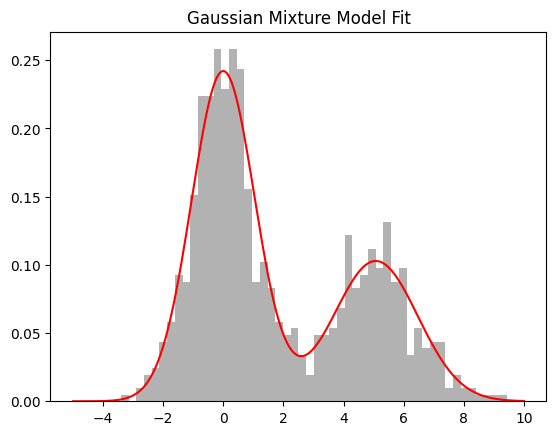

In [4]:
import numpy as np
from sklearn.mixture import GaussianMixture
import matplotlib.pyplot as plt

# Example dataset (skewed)
data = np.concatenate([
    np.random.normal(0, 1, 500),
    np.random.normal(5, 1.5, 300)
]).reshape(-1, 1)

# Fit a GMM with 2 components
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data)

print("Means:", gmm.means_)
print("Variances:", gmm.covariances_)
print("Weights:", gmm.weights_)

# Predict cluster assignments
labels = gmm.predict(data)

# Plot
plt.hist(data, bins=50, density=True, alpha=0.6, color="gray")
x = np.linspace(-5, 10, 1000).reshape(-1, 1)
logprob = gmm.score_samples(x)
pdf = np.exp(logprob)
plt.plot(x, pdf, color="red")
plt.title("Gaussian Mixture Model Fit")
plt.show()